# Pre-submission TODO Audit

## Global Checks

- **[CHECK/POLISH]** Fix periods and punctuation.
- **[CHECK/POLISH]** Check capitalization of $x$ versus $X$.

## Chapter 5: Confidence and Credible Intervals

- **[CHECK/POLISH]** Clarify the confidence interval derivations. The markdown uses an approximate `2` multiplier, while the code uses `z = stats.norm.ppf(0.975)`.
- **[CHECK/POLISH]** Clarify that the "exact Fisher information" interval is really an inverted Wald-style interval, while the actual exact chi-square interval appears only in code.
- **[CHECK/POLISH]** Explain or remove the toy Gamma credible-interval example with `alpha = 4`, `beta = 1.2`; it is not tied to the S&P posterior and interrupts the data analysis flow.
- **[CONTENT]** Add a written bridge from the posterior Gamma distribution to the reported posterior credible interval on both tau and variance scales.

## Chapter 6: Simulating Confidence Intervals

- **[CONTENT]** Store the returned parameter bootstrap quantiles so they can populate the comparison table.
- **[CONTENT]** Fix the nonparametric bootstrap. The current source uses only `n_trials = 10`, computes `sim_npboot = mle(all_samples)` as one aggregate scalar instead of one bootstrap statistic per resample, and the stored output still shows an older failing version.
- **[CONTENT]** Fill the comparison table: Parameter Bootstrap CI, Nonparametric Bootstrap CI, and Metropolis-Hastings CI are blank even though later code tries to compute intervals.
- **[CONTENT]** Fix the Metropolis-Hastings burn-in slice. `sampled_tau[:-burn_in]` drops the last samples; burn-in should drop the first samples.
- **[CHECK/POLISH]** Correct the Metropolis-Hastings prose/comment about the acceptance ratio. The code accepts with `exp(log_p_proposed - log_p_current)`, but the comments/prose are easy to read as the reciprocal or as keeping the wrong state.
- **[CONTENT]** Add basic Metropolis-Hastings diagnostics or at least report acceptance rate, trace behavior, and whether the proposal scale mixes well.

## Chapter 7: Hypothesis Testing

- **[CHECK/POLISH]** Rerun the hypothesis-test code cell and replace the conditional conclusion text with the actual reject/fail-to-reject result.

## Chapter 8: Generalized Likelihood Ratio Test

- **[CHECK/POLISH]** Keep the course-required GLRT convention with the alternative/full-model likelihood on top and rejection for large values; make the notation and prose explicitly match that convention.
- **[CONTENT]** Fix the Wilks comparison. The derivation obtains `2 log Lambda`, but the final line labels it `log Lambda` and compares it to a chi-square cutoff.
- **[CONTENT]** Decide whether to present the exact chi-square test for variance/precision instead of, or alongside, Wilks' theorem. The power-curve code appears to use the exact chi-square distribution but the markdown does not explain that connection.
- **[CONTENT]** Tie the power curve to the actual hypothesis test and data notation. Current code uses hard-coded `n = 10`, `tau_0 = 100`, and a comment saying "maybe can use wilks".

## Chapter 9: Bayesian Hypothesis Testing & Bayes Factor

- **[CONTENT]** Finish the chapter. It stops mid-derivation, has no numerical Bayes factor or interpretation, and is followed by an empty code cell.
- **[CONTENT]** Decide whether `H_A` is a point alternative (`tau = tau_A`) or a composite alternative with a Gamma prior. The current section states a point alternative but then integrates over tau.
- **[CONTENT]** Correct the Bayes factor algebra. The marginal likelihood denominator should involve `beta_n^(alpha_n)`, where `beta_n = beta_0 + 0.5 * sum squares`, not just powers of `beta_0`.
- **[CONTENT]** Separate Bayes factor, prior odds, and posterior odds. The current expression mixes these quantities and uses arbitrary prior probabilities without a final posterior-odds calculation.
- **[CONTENT]** Add code to compute the Bayes factor numerically and a short conclusion interpreting the result.

## Chapter 10: Sufficient Statistics

- **[CONTENT]** Connect the sufficient statistic back to the earlier likelihood/posterior work in some way, maybe bring in rao blackwell or sufficiency principle/likelihood principle, and then conclude 




# The Quest for Precision: A Bayesian and Frequentist Journey Through Statistical Inference
## Stats 200Q Book: Normal Inverse-Variance Distribution with Gamma Prior

My book exploring Bayesian inference for the inverse-variance (i.e. precision) of a Normal distribution with known mean, using the **Gamma** distribution as a prior for $\tau = 1/\sigma^2$.

Author: Andrew Su

Notation choices:
- Jack advised using $\tau$ and it mostly makes all derivations a lot simpler.
- I use $\exp(x)$ instead of $e^x$ sometimes for readability.

AI Disclaimer: I used some AI to help me generate plots and polish work, but all the derivations, written analysis, and non-plot code is my own.

## Chapter 1: Distribution, Dataset, and Details

Before we embark on this statistical journey, which will involve a healthy mix of mathematical derivation and programmed simulation, we must first establish key tools (Python packages) needed for our analysis.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import pymc as pm
import arviz as az
import statsmodels.api as sm
from ipywidgets import interact, FloatSlider, IntSlider

### Data: S&P 500 Log Returns

Next, we choose a real-world dataset to give our statistical theory some grounding and application. Henceforth we will use daily S&P 500 log returns as our observed data $x_1, \ldots, x_n$, assuming known mean 0. This means the model 
$$x_i \sim \mathcal{N}(0, 1/\tau), \quad \quad \text{ where }  \tau = 1/\sigma^2$$
will represent the precision, or inverse variance, of daily log returns. Our goal is to estimate $\tau$, which has a Gamma prior during Bayesian analysis. Whenever I report variance, it is the derived scale $\sigma^2 = 1/\tau$.

In [9]:
# Pull daily S&P 500 data
sp500 = yf.download("^GSPC", start="2000-01-01", end="2025-12-31")

# Compute one-dimensional log returns
close = sp500["Close"].squeeze()
log_returns_series = np.log(close / close.shift(1)).dropna()
log_returns = log_returns_series.to_numpy()

print(log_returns_series.describe())

[*********************100%***********************]  1 of 1 completed

count    6537.000000
mean        0.000238
std         0.012216
min        -0.127652
25%        -0.004736
50%         0.000641
75%         0.005876
max         0.109572
Name: ^GSPC, dtype: float64


More on our dataset: This is a one-dimensional list of daily S&P log returns from January 1, 2000 to December 31, 2025, during which there were 6537 trading days. The mean is 0.000238, and sample std is 0.012216. We therefore make two assumptions that may reduce the validity of our statistical analysis: 
- We assume the mean to be known at exactly 0, while in reality it is slightly positive.
- We assume S&P log returns to be normally distributed when, in fact, the distribution has larger tails.

However, our simplified model will suffice as a pedagogical example for our statistical methods.

### Preface

Ok. Last thing before we start. The underlying goal of this entire notebook is to go on a journey to better understand the variance of the stock market. Daily returns move around, sometimes quietly and sometimes violently, and we want a statistical way to describe that movement. In this book, we'll usually work with $\tau = 1/\sigma^2$, the inverse variance, but the bigger question is really about volatility: how spread out are the returns, and how certain can we be about that spread?

To guide the journey, we will meet two mentors: **Freddy the Frequentist** and **Betty the Bayesian**. They both look at the same data and the same Normal model, but they think about probability in different ways.

Freddy the Frequentist believes that probability is tied to long-run repetition. To Freddy, the true value of $\tau$ is fixed but unknown, and the randomness comes from the sample we happened to observe. So Freddy asks questions like: if we repeated this data collection process many times, how would our estimator behave? How often would our interval contain the true value? How often would our test reject?

Betty the Bayesian believes that probability can also describe uncertainty or belief. To Betty, the observed data are fixed, but $\tau$ is uncertain to us, so she represents that uncertainty with a prior distribution and updates it with the likelihood. After seeing the data, Betty can talk directly about a posterior distribution for $\tau$ and ask where most of its probability lies.

So this book is not just about the "best way to estimate $\tau$," but rather two underlying philosophies and what that implies about your understanding of statistics. Freddy and Betty will help us think about estimation, bias and variance, asymptotic approximations, intervals, simulations, hypothesis testing, and sufficient statistics. The next chapter starts with the first step of the journey: what does each mentor choose as the best estimate of stock market precision?

## Chapter 2: Frequentist vs. Bayesian Estimation

The first question one might ask when trying to predict the variance of the stock market is, 

**Well, what is the variance?** 



### Frequentist (Maximum Likelihood Estimate)

Approaching Freddy the Frequentist, we remember that he believes $\tau$ is fixed but unknown. After asking him how he'd estimate $\tau$, he says,

*"I'd find the value of $\tau$ that makes the data most likely."*

In other words, Freddy's answer is to use the likelihood. Using the model, we plug in a possible value of $\tau$, and ask how likely our observed returns would be under that value. Then try another value of $\tau$, and another. The maximum likelihood estimate, then, is the value that makes the observed sample most likely. 

For a single observed datapoint $x_i$, we have 
$$L_{x_i}(\tau) = f_\tau (x_i) = \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau {x_i}^2}{2}\right)}$$

which is the Normal PDF parameterized with $\tau$. So, the likelihood of all the observed data $x = x_1, \ldots, x_n$ is 
$$
L_x (\tau) 
= \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau x_i^2}{2}\right)}
= (\frac{\tau}{2\pi})^{n/2} e^ {\left(-\frac{\tau}{2} \sum_{i=1}^n x_i^2\right)}
$$

Then we want to find the value of $\tau$ that maximizes the likelihood, or
$$\hat \tau = \arg \max_\tau \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau x_i^2}{2}\right)}$$

Taking log likelihood, we have
$$\ell_x (\tau)= 
\log L_x (\tau) =
\frac{n}{2} \ln(\tau) - \frac{n}{2} \ln (2\pi) - \frac{\tau}{2} \sum_{i=1}^n x_i^2
$$

And taking the derivative gets
$$ \frac{\partial \ell}{\partial \tau} =
\frac{n}{2 \tau} - \frac{1}{2} \sum_{i=1}^n x_i^2 
$$

Finally, setting to 0, we have
$$ \frac{n}{2\tau} = \frac{1}{2} \sum_{i=1}^n x_i^2$$
$$ \hat \tau = \frac{n}{\sum_{i=1}^n x_i^2}$$

This is our frequentist estimator, the **Maximum Likelihood Estimate**.


### Bayesian (Posterior Mean)

Approaching Betty the Bayesian, we ask the same question: how would she estimate $\tau$? Betty agrees with Freddy that the likelihood matters, but she does not want the data to be the entire story. Before seeing this particular sample of returns, she is willing to write down a rough belief about what values of $\tau$ seem plausible.

Betty says,

*"I'd start with what I believe about $\tau$, then update that belief after seeing the data."*

The prior represents what Betty believes before looking at the observed returns. The likelihood represents what the data says. The posterior combines the two. Since $\tau$ is positive and continuous, the Gamma distribution works neatly. 

For now, we will keep the prior general:
$$\tau = 1/\sigma^2 \sim \Gamma(\alpha_0, \beta_0),$$
where $\beta_0$ is the rate parameter. Written out, the prior density is
$$ f(\tau) 
= \frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)} \tau ^ {\alpha_0 - 1} e^ {- \beta_0 \tau}. $$

Let's proceed with deriving the posterior distribution. Bayes' Theorem gives us:
$$ f(\tau | x) = \frac{f(x | \tau)f(\tau)}{f(x)} $$

We already have $f(\tau)$ from above. Since our model is written directly in terms of $\tau$, the likelihood of the observed data is the same as when we derived it with Freddy:

$$f(x | \tau) = \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{x_i^2\tau}{2}\right)}$$

Note the change in notation compared to frequentist, $f(x | \tau)$ versus $f_\tau (x_i)$. Plugging these into our formula for the posterior, we get

$$ 
\begin{align*}
f(\tau | x) &= \frac{\left( \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{x_i^2\tau}{2}\right)} \right)   \left( \frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)} \tau ^ {\alpha_0 - 1} e^ {- \beta_0 \tau} \right)}{f(x)} \\
&\propto \tau ^{n/2} \cdot e^{-\frac{\tau}{2} \sum_{i=1}^n x_i^2} \cdot \tau ^ {\alpha_0 - 1} e ^{-\beta_0 \tau} \\
&\propto \tau ^ {\alpha_0 + n/2 - 1} \cdot e^ {-\tau \left( \frac 12 \sum_{i=1}^n x_i^2 + \beta_0\right)}
\end{align*}
$$

Since this has the same kernel as a Gamma density, the posterior distribution is

$$
\tau \mid x \sim \Gamma\left(\alpha_n = \alpha_0 + \frac{n}{2}, \beta_n = \beta_0 + \frac 12 \sum_{i=1}^n x_i^2\right).
$$

Finally, to get the posterior mean for $\tau$, we have
$$ \hat \tau_{\text{Bayes}}
= \mathbb E[\tau | x]
= \frac{\alpha_n}{\beta_n}
= \frac{\alpha_0 + \frac{n}{2}}{\beta_0 + \frac 12 \sum_{i=1}^n x_i^2}
= \frac{n + 2\alpha_0}{\sum_{i=1}^n x_i^2 + 2\beta_0}. $$



### Bringing in the Data

Now that both estimators are derived generally, we can choose an actual prior for the S&P 500 data. From now on, we'll set $\alpha_0 = 2, \beta_0 = 0.0002$. This way,
$$\mathbb E[\tau] = \frac{\alpha_0}{\beta_0} = \frac{2}{0.0002} = 10000.$$
Using some approximations, we have
$$\sigma \approx \sqrt{1/\mathbb E[\tau]} = \sqrt{1/10000} = 0.01$$
which intuitively means we expect log returns to have a standard deviation in the ballpark of 1%. Note that this is "back-of-the-envelope" because while
$$
\tau = 10000 \implies \sigma = 0.01, \quad \quad \mathbb E[\tau] = 10000 \nRightarrow \mathbb E [\sigma] = 0.01.
$$


At the same time, our confidence is low, so
$$\mathrm{Var}(\tau) = \frac{\alpha_0}{\beta_0^2} = \frac{2}{0.0002^2}$$
is quite large.

With that prior choice, we can now calculate exact estimators for $\tau$ on our data. Our estimators are:

Frequentist: 
$$ \hat \tau = \frac{n}{\sum x_i^2}$$
Bayesian: 
$$ \hat \tau = \frac{\alpha_n}{\beta_n} = \frac{n + 2\alpha_0}{\sum x_i^2 + 2\beta_0} $$

In [3]:
def maximum_likelihood(log_returns):
    x = np.asarray(log_returns).squeeze()
    return len(x) / np.sum(x ** 2)

def posterior_mean(log_returns, alpha_0 = 2.0, beta_0 = 0.0002):
    x = np.asarray(log_returns).squeeze()
    alpha_n = alpha_0 + len(x) / 2
    beta_n = beta_0 + 0.5 * np.sum(x ** 2)
    return alpha_n / beta_n

def maximum_likelihood_variance(log_returns):
    x = np.asarray(log_returns).squeeze()
    return np.mean(x ** 2)

def posterior_mean_variance(log_returns, alpha_0 = 2.0, beta_0 = 0.0002):
    x = np.asarray(log_returns).squeeze()
    return (np.sum(x ** 2) + 2 * beta_0) / (len(x) + 2 * (alpha_0 - 1))

In [4]:
print(f"Maximum likelihood tau: {maximum_likelihood(log_returns):.4f}")
print(f"Posterior mean tau: {posterior_mean(log_returns):.4f}")
print(f"Difference: {maximum_likelihood(log_returns) - posterior_mean(log_returns):.4f}")

Maximum likelihood tau: 6699.9624
Posterior mean tau: 6701.3147
Difference: -1.3524


The MLE is almost identical to the posterior mean, with the posterior mean slightly higher because it is pulled toward the prior mean for $\tau$. As $n$ grows, the prior contribution becomes negligible, so the posterior mean approaches the MLE for these estimators. Here's a quick proof for our specific estimators.
$$\lim_{n \rightarrow \infty} \hat{\tau}_{\text{Bayes}} = \lim_{n \rightarrow \infty} \frac{n + 2\alpha_0}{\sum x_i^2 + 2\beta_0} = \lim_{n \rightarrow \infty} \frac{1 + \frac{2\alpha_0}{n}}{\frac{1}{n}\sum x_i^2 + \frac{2\beta_0}{n}} = \frac{1}{\frac{1}{n}\sum x_i^2} = \hat{\tau}_{\text{MLE}}$$

### Bias and Variance

Now that we have two different estimators, how do we know which is better? As an initial method of evaluating these estimators, we can look at their bias and variance. For an estimator $\hat\tau$, we define

$$
\mathrm{Bias}(\hat\tau) = \mathbb E[\hat\tau] - \tau
$$

and

$$
\mathrm{Var}(\hat\tau) = \mathbb E\left[(\hat\tau - \mathbb E[\hat\tau])^2\right].
$$

There is one small complication here. We have been using inverse variance, $\tau = 1/\sigma^2$, because it makes the likelihood and Gamma posterior much cleaner. But bias and variance are much harder to derive directly for estimators of $\tau$, since $\hat\tau_{\text{MLE}} = n/\sum X_i^2$ is a reciprocal of a random sum. 

So for this subsection only, we temporarily switch to the variance scale. Let

$$
\theta = \sigma^2 = \frac{1}{\tau},
$$

so that

$$
X_i \sim \mathcal N(0, \theta).
$$

#### Bias and Variance of MLE

If we estimate variance directly, the maximum likelihood estimator becomes

$$
\hat\theta_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^n X_i^2.
$$

To find its bias, we use the fact that $\mathbb E[X_i^2] = \theta$ via the definition of variance:

$$
\begin{align*}
\mathbb E[\hat\theta_{\text{MLE}}]
&= \mathbb E\left[\frac{1}{n}\sum_{i=1}^n X_i^2\right] \\
&= \frac{1}{n}\sum_{i=1}^n \mathbb E[X_i^2] \\
&= \frac{1}{n}(n\theta) \\
&= \theta.
\end{align*}
$$

Therefore,

$$
\mathrm{Bias}(\hat\theta_{\text{MLE}}) = \mathbb E[\hat\theta_{\text{MLE}}] - \theta = 0.
$$

So the MLE for variance is **unbiased**.

For the variance of the estimator, we use the fact that $\frac{X_i^2}{\theta} \sim \chi^2_1$, so $X_i^2$ has variance $2\theta^2$:

$$
\begin{align*}
\mathrm{Var}(\hat\theta_{\text{MLE}})
&= \mathrm{Var}\left(\frac{1}{n}\sum_{i=1}^n X_i^2\right) \\
&= \frac{1}{n^2}\sum_{i=1}^n \mathrm{Var}(X_i^2) \\
&= \frac{1}{n^2}(n \cdot 2\theta^2) \\
&= \frac{2\theta^2}{n}.
\end{align*}
$$

#### Bias and Variance of Posterior Mean

The posterior mean for the variance is:

$$
\hat\theta_{\text{Bayes}} = \frac{\beta_0 + \frac{1}{2}\sum_{i=1}^n x_i^2}{\alpha_0 + n/2 - 1}
$$

Taking expectation:
$$
\begin{align*}
\mathbb{E}[\hat\theta_{\text{Bayes}}]
&= \frac{\beta_0 + \frac{1}{2}\sum_{i=1}^n \mathbb{E}[X_i^2]}{\alpha_0 + n/2 - 1} \\
&= \frac{\beta_0 + n\theta/2}{\alpha_0 + n/2 - 1}
\end{align*}
$$

$$
\mathrm{Bias}(\hat\theta_{\text{Bayes}}) = \frac{\beta_0 - (\alpha_0 - 1)\theta}{\alpha_0 + n/2 - 1}
$$

Which is a nonzero value with sign depending on the prior.

For the variance:

$$
\begin{align*}
\mathrm{Var}(\hat\theta_{\text{Bayes}})
&= \frac{1}{(\alpha_0 + n/2 - 1)^2} \cdot \frac{1}{4} \cdot \mathrm{Var}\!\left(\sum_{i=1}^n X_i^2\right) \\
&= \frac{1}{(\alpha_0 + n/2 - 1)^2} \cdot \frac{2n\theta^2}{4} \\
&= \frac{n\theta^2}{2(\alpha_0 + n/2 - 1)^2}
\end{align*}
$$

Therefore, the frequentist estimator is unbiased while the Bayesian estimator may be biased due to the prior. In return, the Bayesian estimator can have smaller variance because the prior stabilizes the estimate.

Replicating the simulation in `mle_gamma.qmd`: we use the observed MLE, $\hat\tau_{\text{MLE}}$, as a plug-in true value and simulate from a Normal distribution with $\mu = 0$ and $\tau = \hat\tau_{\text{MLE}}$. We use $n = 100$ to make the difference visible. The simulation lets us compare the MLE behavior with posterior mean behavior under repeated sampling.


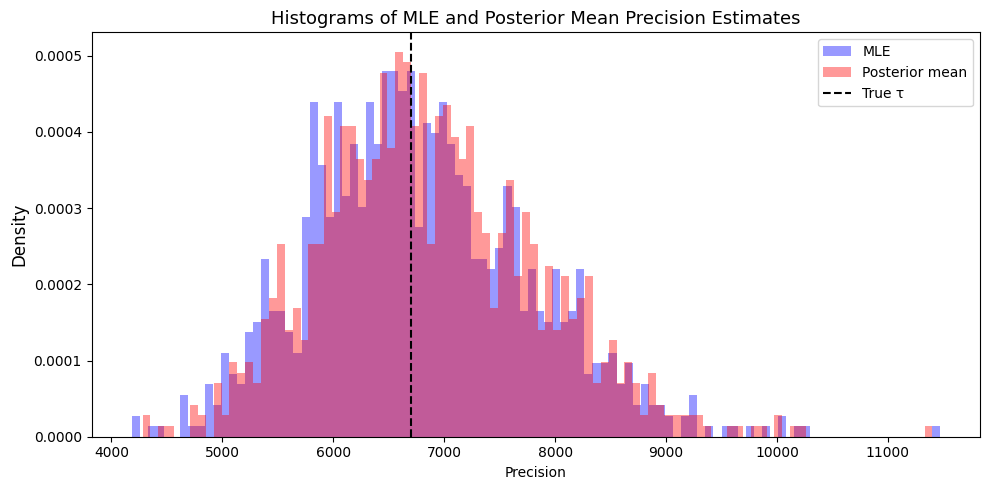

MLE bias:      87.600566
Bayes bias:    168.779000
MLE variance:  9.75e+05
Bayes variance:9.44e+05


In [7]:
true_tau = maximum_likelihood(log_returns)
num_simulations = 1000
num_samples = 100

mle_estimates = []
pm_estimates = []

for _ in range(num_simulations):
    simulated_log_returns = np.random.normal(0, np.sqrt(1 / true_tau), num_samples)
    mle_estimates.append(maximum_likelihood(simulated_log_returns))
    pm_estimates.append(posterior_mean(simulated_log_returns))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mle_estimates, bins=100, density=True, color='blue', alpha=0.4, label='MLE')
ax.hist(pm_estimates, bins=100, density=True, color='red', alpha=0.4, label='Posterior mean')
ax.axvline(true_tau, color='black', linestyle='--', label='True τ')

ax.set_title('Histograms of MLE and Posterior Mean Precision Estimates', fontsize=13)
ax.set_xlabel('Precision')
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"MLE bias:      {np.mean(mle_estimates) - true_tau:.6f}")
print(f"Bayes bias:    {np.mean(pm_estimates) - true_tau:.6f}")
print(f"MLE variance:  {np.var(mle_estimates):.2e}")
print(f"Bayes variance:{np.var(pm_estimates):.2e}")

As we can see, the MLE is much less biased whereas the PM has less variance. 

## Chapter 3: Evaluating Estimators

Previously, Freddy and Betty gave us two ways to estimate the spread of returns. Bias and variance were two easy metrics for judging those estimators, but we don't have an absolute metric of which one is better. Moreover, how do we know if an estimator is the *best possible estimator*?

This chapter is about building that larger evaluation toolkit. We move from simple bias and variance into mean squared error, Fisher information, and the Cramer-Rao lower bound. 


### Proof Exercise

Before we can talk about the Cramer-Rao lower bound, we need one useful identity about the likelihood. In Chapter 2, we used the first derivative of the log-likelihood, $\ell'(\theta)$, to find the MLE. Here, we give that derivative a name: it is the **score**.

The score measures the local slope of the log-likelihood. If small changes in $\theta$ cause the log-likelihood to change a lot, then the data are telling us something precise about the parameter. Curvature gives the same kind of message: a sharply curved log-likelihood means the data point strongly toward some values of $\theta$ and away from others. The next identity shows that these two ways of measuring information are mathematically connected:

<div style="border-left: 3px solid gray; padding-left: 10px; margin: 10px 0;">

We want to show 
$$
\mathrm{Var}[\ell'(\theta)] = -\mathbb E[\ell''(\theta)]
$$

We can start by finding $\ell''(\theta)$:

$$
    \ell''(\theta) = \frac{\partial}{\partial \theta} \ell'(\theta) = \frac{\partial}{\partial \theta} \frac{f'}{f} = \frac{f''}{f} - \left(\frac{f'}{f}\right)^2 = \frac{f''}{f} - (\ell'(\theta))^2
$$
And then we take the expectation to get

$$\mathbb{E}[\ell''(\theta)] = \int \left(\frac{f''}{f} - (\ell'(\theta))^2\right) f\,dx = \int f''\,dx - \mathbb{E}[(\ell')^2]$$

The first term vanishes:

$$\int f''\,dx = \frac{\partial^2}{\partial\theta^2}\int f\,dx = 0$$

So:

$$\mathbb{E}[\ell''] = -\mathbb{E}[(\ell')^2]$$

On the other hand, we have
$$
\mathrm{Var}[\ell'(\theta)] = \mathbb E[(\ell'(\theta))^2] - \mathbb E[\ell'(\theta)]^2.
$$
We know that $\mathbb E[\ell'(\theta)] = 0$, so
$$
\mathrm{Var}[\ell'(\theta)] = \mathbb E[(\ell'(\theta))^2]
$$

So finally, 

$$\boxed{\text{Var}(\ell'(\theta)) = -\mathbb{E}[\ell''(\theta)]}$$

</div>



This result gives us the definition we need. The quantity that measures how much information the likelihood carries about $\theta$ is called **Fisher information**. For one parameter, we define it as the variance of the score:

$$
I(\theta) = \mathrm{Var}[\ell'(\theta)].
$$

Because of the identity we just proved, we can also compute it from the expected curvature of the log-likelihood:

$$
I(\theta) = -\mathbb E[\ell''(\theta)].
$$

So Fisher information ties together the two pictures above. A flatter log-likelihood means less information and more uncertainty about the parameter; a sharper log-likelihood means more information and less uncertainty. This will make the Cramer-Rao lower bound easier to compute later in this chapter.




### MSE Simulation

Bias and variance each isolate one part of estimator behavior. Mean squared error combines them into one number:

$$
\mathrm{MSE}(\hat\theta) = \mathbb E[(\hat\theta - \theta)^2]
= \mathrm{Var}(\hat\theta) + \mathrm{Bias}(\hat\theta)^2.
$$

This is useful for comparing Freddy and Betty because Betty's estimator may accept some bias from the prior in exchange for lower variance. MSE gives us a way to ask whether that tradeoff helps or hurts overall.

For this pedagogical MSE example, I temporarily stay on the generic variance parameter $\theta = \sigma^2$, which keeps the estimators easier to compare directly.

We have estimators:

Frequentist: 
$$ \hat \theta = \frac{1}{n} \sum X_i^2 $$
Bayesian: 
$$ \hat \theta = \frac{\sum X_i^2 + 2\beta_0}{n + 2(\alpha_0 - 1)}  
\quad \quad \quad \quad
\hat \tau = \frac{n + 2\alpha_0} {\sum X_i^2 + 2\beta_0} 
$$

We've proven already that the MLE is unbiased, so the MSE of the MLE estimator is just its variance:
$$
\frac{2\theta^2}{n}.
$$

For Betty's estimator, the prior can change both the bias and the variance depending on where the true $\theta$ is relative to the prior mean. Rather than only stare at the formula, we can simulate repeated samples and watch the tradeoff directly.


True theta: 2.0000  MLE MSE: 0.3977  PM MSE: 0.3619


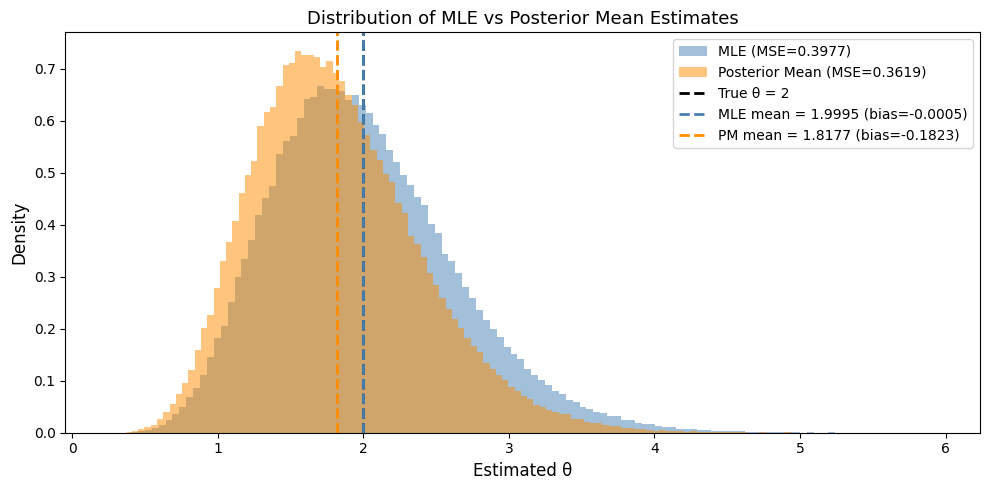

In [ ]:
n = 20
n_trials = 200000
true_theta = 2

mle_estimates = []
pm_estimates = []
mle_mses = []
pm_mses = []

for _ in range(n_trials):
    sim_vals = np.random.normal(0, np.sqrt(true_theta), n)
    mle = maximum_likelihood_variance(sim_vals)
    pm = posterior_mean_variance(sim_vals)
    mle_estimates.append(mle)
    pm_estimates.append(pm)
    mle_mses.append((mle - true_theta) ** 2)
    pm_mses.append((pm - true_theta) ** 2)

mle_mse = np.mean(mle_mses)
pm_mse = np.mean(pm_mses)
mle_mean = np.mean(mle_estimates)
pm_mean = np.mean(pm_estimates)

print(f"True theta: {true_theta:.4f}  MLE MSE: {mle_mse:.4f}  PM MSE: {pm_mse:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mle_estimates, bins=120, density=True, color='steelblue', alpha=0.5, label=f'MLE (MSE={mle_mse:.4f})')
ax.hist(pm_estimates,  bins=120, density=True, color='darkorange', alpha=0.5, label=f'Posterior Mean (MSE={pm_mse:.4f})')
ax.axvline(true_theta, color='black', linestyle='--', linewidth=2, label=f'True θ = {true_theta}')
ax.axvline(mle_mean, color='steelblue', linestyle='--', linewidth=2, label=f'MLE mean = {mle_mean:.4f} (bias={mle_mean - true_theta:+.4f})')
ax.axvline(pm_mean,  color='darkorange', linestyle='--', linewidth=2, label=f'PM mean = {pm_mean:.4f} (bias={pm_mean - true_theta:+.4f})')

ax.set_title('Distribution of MLE vs Posterior Mean Estimates', fontsize=13)
ax.set_xlabel('Estimated θ')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

The first simulation fixes one true variance value. But the Bayesian estimator depends on the prior, so its performance can change depending on whether the true variance is near or far from the prior mean. The next simulation sweeps across possible true values of $\theta$ and compares the MSE of both estimators across that range.


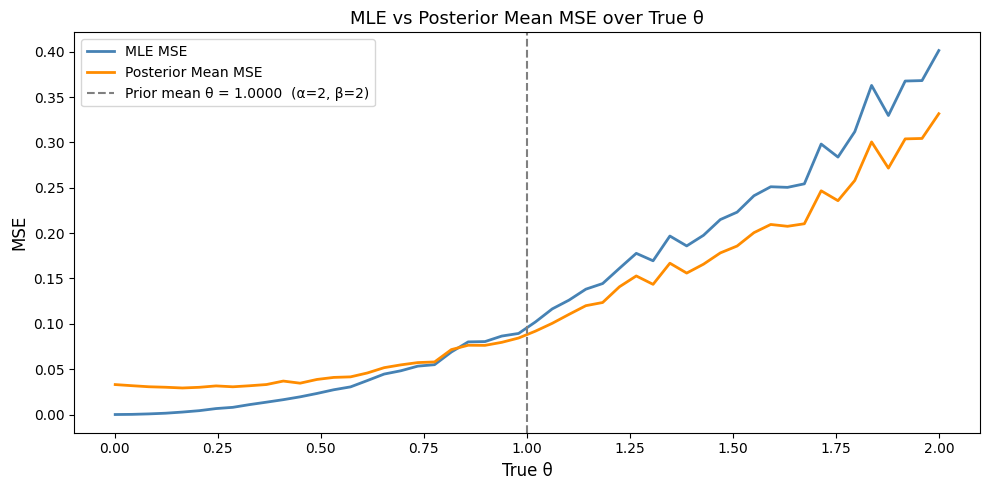

In [ ]:
n = 20
n_trials = 1000
alpha_0, beta_0 = 2, 2
prior_mean_theta = beta_0 / (alpha_0 - 1)

true_thetas = np.linspace(0.001, 2.0, 50)

mle_mses = []
pm_mses = []

for true_theta in true_thetas:
    mle_sq_errs = []
    pm_sq_errs = []
    for _ in range(n_trials):
        sim_vals = np.random.normal(0, np.sqrt(true_theta), n)
        mle = maximum_likelihood_variance(sim_vals)
        pm = posterior_mean_variance(sim_vals, alpha_0=alpha_0, beta_0=beta_0)
        mle_sq_errs.append((mle - true_theta) ** 2)
        pm_sq_errs.append((pm - true_theta) ** 2)
    mle_mses.append(np.mean(mle_sq_errs))
    pm_mses.append(np.mean(pm_sq_errs))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(true_thetas, mle_mses, color='steelblue', linewidth=2, label='MLE MSE')
ax.plot(true_thetas, pm_mses, color='darkorange', linewidth=2, label='Posterior Mean MSE')
ax.axvline(prior_mean_theta, color='gray', linestyle='--', linewidth=1.5,
           label=f'Prior mean θ = {prior_mean_theta:.4f}  (α={alpha_0}, β={beta_0})')

ax.set_title('MLE vs Posterior Mean MSE over True θ', fontsize=13)
ax.set_xlabel('True θ')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

### Bayesian MSE

The previous simulation judges both estimators in Freddy's language: fix a true value of $\theta$, repeatedly sample new data, and average the squared error over those repeated samples. That is the traditional frequentist MSE,

$$
\mathrm{MSE}(t, \theta)
= \mathbb E_{X \mid \theta}[(t(X) - \theta)^2],
$$

where $t(X)$ is the estimator.

Betty might object that this evaluation is a little unfair to her. Her estimator was not designed only for one fixed value of $\theta$ while ignoring prior uncertainty. The whole Bayesian idea is that before seeing the data, $\theta$ is uncertain. So from Betty's perspective, evaluating an estimator separately at each fixed $\theta$ throws away the philosophy that created the estimator in the first place.

Instead, Betty would average the frequentist MSE over her prior belief about $\theta$. In this form, the Bayesian MSE is

$$
\mathrm{BMSE}(t)
= \int \mathrm{MSE}(t, \theta)\,\pi(\theta)\,d\theta,
$$

where $\pi(\theta)$ is the prior density for $\theta$. In words, we first ask how well the estimator performs if the true variance were $\theta$, and then average that performance over the values of $\theta$ Betty thought were plausible before seeing the data.

Under squared-error loss, the estimator that minimizes this Bayesian MSE is the posterior mean. This is another way to understand Betty's choice: she is not choosing the posterior mean because it wins at every fixed value of $\theta$, but because it is optimal after averaging error across her prior uncertainty and updating with the observed data.

This shows why Betty may not agree that ordinary MSE over fixed values of $\theta$ tells the whole story. Freddy asks how the estimator performs under repeated sampling for each fixed truth. Betty asks how the estimator performs after averaging across the truths her prior considered plausible.



### Cramer-Rao Lower Bound

The MSE simulations tell us how Freddy and Betty behave under repeated sampling. The next question is more theoretical: for unbiased estimators, is there a lowest possible variance that no estimator can beat?

The Cramer-Rao bound answers that question. Under regularity conditions, for any unbiased estimator $t(X)$,
$$
\mathrm{Var}[t(X)] \geq \frac{1}{\mathrm{Var}[\ell'_X(\theta)]}.
$$
Using the proof exercise above, this is the same as
$$
\mathrm{Var}[t(X)] \geq \frac{1}{-\mathbb E[\ell''_X(\theta)]}.
$$

So the score identity turns an abstract lower bound into something we can calculate from the log-likelihood.

From earlier, we have
$$ \ell'(\theta) =
- \frac{n}{2 \theta} + \frac{1}{2\theta^2} \sum_{i=1}^n X_i^2 
$$
And so
$$ 
\ell''(\theta) =  \frac{n}{2 \theta^2} - \frac{1}{\theta^3} \sum_{i=1}^n X_i^2 
$$
Taking expected value, we get
$$
\mathbb E[\ell''(\theta)] = \frac{n}{2 \theta^2} - \frac{1}{\theta^3} E[\sum_{i=1}^n X_i^2] 
= \frac{n}{2 \theta^2} - \frac{n\theta}{\theta^3}  
= -\frac{n}{2\theta^2}
$$
And so our CRLB is
$$
\frac{2\theta^2}{n}.
$$
This is the same as the variance of our MLE estimator, so in this Normal known-mean model, Freddy's MLE for variance reaches the Cramer-Rao lower bound. Among unbiased estimators, it is as efficient as possible.


## Chapter 4: Asymptotic Distribution of MLE

### 1) Distribution of the MLE

We have our frequentist key terms:
$$
\ell_x(\tau) = \frac{1}{2} \log \tau - \frac{\tau}{2} x_i^2
$$

$$
\hat \tau = \frac{n}{\sum X_i^2}
$$

So 

$$
\sqrt{n}(\hat \tau - \tau_0) \sim \mathrm{Normal}(0, \frac{1}{\mathrm{Var}[\ell'_{X_1} (\tau_0)]})
$$

Deriving with $\tau$, we get
$$
\ell''(\tau) = -\frac{1}{2 \tau^2} \implies \mathbb E[\ell ''] = -\frac{1}{2 \tau_0^2} = - \mathrm {Var}[\ell']
$$

Plugging in, we get

$$
\sqrt{n}(\hat \tau - \tau_0) \sim \mathrm{Normal}(0, 2 \tau_0^2)
$$

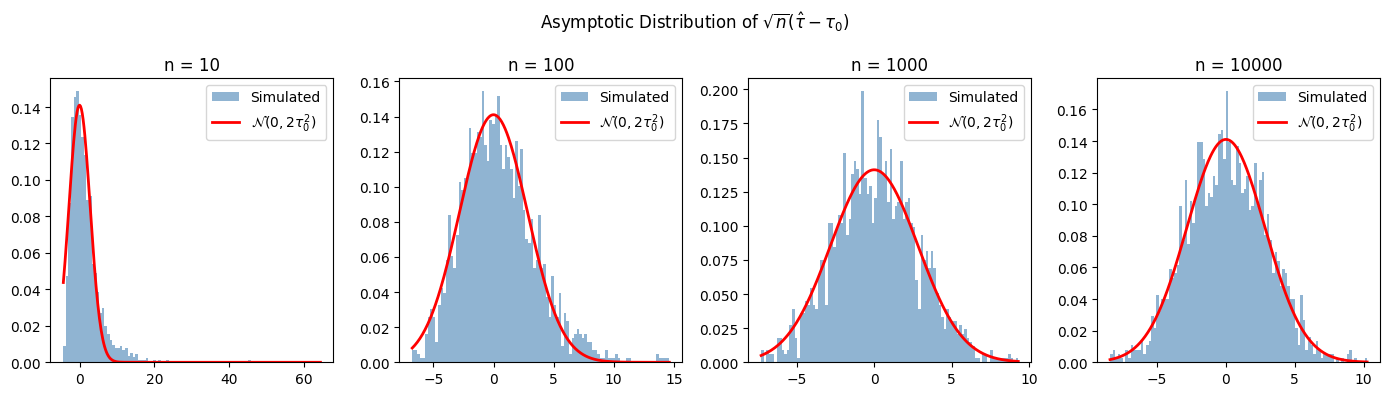

True τ₀ = 2

       n      mean(τ̂)
      10      2.516385
     100      2.042459
    1000      2.004367
   10000      2.000862


In [ ]:
tau_0 = 2
mu = 0
n_trials = 2000

sample_sizes = [10, 100, 1000, 10000]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

all_tau_hats = {}

for ax, n in zip(axes, sample_sizes):
    estimates = np.zeros(n_trials)
    tau_hats = np.zeros(n_trials)

    for b in range(n_trials):
        # Step 1: Draw n samples from N(mu, 1/tau_0)
        X = np.random.normal(loc=mu, scale=1/np.sqrt(tau_0), size=n)

        # Step 2: Compute MLE  tau_hat = n / sum((X - mu)^2)
        tau_hat = n / np.sum((X - mu)**2)
        tau_hats[b] = tau_hat

        # Step 3: Compute the centered, scaled quantity
        estimates[b] = np.sqrt(n) * (tau_hat - tau_0)

    all_tau_hats[n] = tau_hats

    # Step 4: Plot histogram
    ax.hist(estimates, bins=100, density=True, alpha=0.6, color='steelblue', label='Simulated')

    # Step 5: Overlay theoretical limit N(0, 2*tau_0^2)
    asymp_var = 2 * tau_0**2
    x = np.linspace(estimates.min(), estimates.max(), 300)
    ax.plot(x, stats.norm.pdf(x, 0, np.sqrt(asymp_var)),
            'r-', lw=2, label=r'$\mathcal{N}(0, 2\tau_0^2)$')

    ax.set_title(f'n = {n}')
    ax.legend()

plt.suptitle(r'Asymptotic Distribution of $\sqrt{n}(\hat\tau - \tau_0)$')
plt.tight_layout()
plt.show()

print(f"True τ₀ = {tau_0}")
print(f"\n{'n':>8}  {'mean(τ̂)':>12}")
for n, tau_hats in all_tau_hats.items():
    print(f"{n:>8}  {np.mean(tau_hats):>12.6f}")

## Chapter 5: Confidence and Credible Intervals

### Frequentist -- Confidence Intervals

Recall our key terms:

$$
\ell(\tau) = \frac{1}{2} \log \tau - \frac{\tau}{2} X_i^2
$$

$$
\hat \tau = \frac{n}{\sum X_i^2}
$$

$$
\mathbb E[\ell ''] = -\frac{1}{2 \tau_0^2} = - \mathrm {Var}[\ell']
$$

$$
\hat \tau \sim \mathrm{Normal}(\tau, \frac{2\tau^2}{n})
$$

Strategy 1: CI with plug-in Fisher information

$$
\hat \tau \sim \mathrm{Normal}(\tau, \frac{2\tau^2}{n}) 
$$

So

$$
\tau = \hat \tau \pm 2\sqrt{\frac {2 \tau^2}{n}}
$$

Since the standard error $\sqrt{2\tau^2/n}$ contains $\tau$, we substitute with $\hat \tau$.

$$
\tau = \hat \tau \pm 2\sqrt{\frac {2 \hat \tau^2}{n}}
$$

So we have confidence bounds
$$
\hat \tau - 2 \hat \tau \sqrt{\frac {2}{n}} \leq \tau \leq \hat \tau + 2 \hat \tau \sqrt{\frac {2}{n}}
$$

<!-- $$
\hat \tau (1 - 2 \sqrt{\frac{2}{n}}) \leq \tau \leq \hat \tau (1 + 2 \sqrt{\frac{2}{n}})
$$ -->


Strategy 2: CI with exact Fisher information

Suppose we don't substitute $\tau = \hat \tau$. Then we have 

$$
-2 \leq \frac{\hat \tau - \tau}{\tau \sqrt{2/n}} \leq 2
$$

$$
-2 \sqrt{\frac{2}{n}} \leq \frac{\hat \tau - \tau}{\tau} \leq 2 \sqrt{\frac{2}{n}}
$$

$$
-2 \sqrt{\frac{2}{n}} \leq \frac{\hat \tau}{\tau} - 1 \leq 2 \sqrt{\frac{2}{n}}
$$

$$
1-2 \sqrt{\frac{2}{n}}  \leq \frac{\hat \tau}{\tau} \leq 1 + 2 \sqrt{\frac{2}{n}} 
$$

$$
\frac{\hat \tau}{1+2 \sqrt{\frac{2}{n}}}  \leq \tau \leq \frac{\hat \tau}{1 - 2 \sqrt{\frac{2}{n}} }
$$

$$
\frac{\hat \tau}{1+\sqrt{8 / n}}  \leq \tau \leq \frac{\hat \tau}{1 - \sqrt{ 8 / n}} 
$$





### Bayesian -- Credible Interval

Recall our posterior distribution: 

$$
\tau | x \sim \Gamma (\alpha_n, \beta_n), \quad \alpha_n = \alpha_0 + \frac{n}{2}, \quad \beta_n = \beta_0 + \frac{\sum x_i^2}{2}
$$


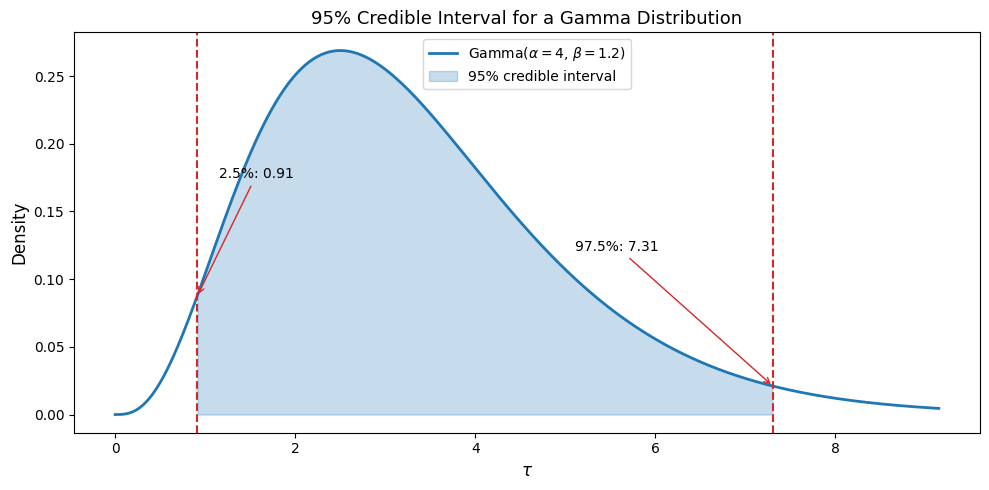

In [ ]:
# 95% credible interval on a Gamma distribution

toy_alpha = 4
toy_beta = 1.2  # rate parameter
toy_scale = 1 / toy_beta

lower, upper = stats.gamma.ppf([0.025, 0.975], a=toy_alpha, scale=toy_scale)
x = np.linspace(0, stats.gamma.ppf(0.995, a=toy_alpha, scale=toy_scale), 1000)
pdf = stats.gamma.pdf(x, a=toy_alpha, scale=toy_scale)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf, color="#1f77b4", linewidth=2, label=fr"Gamma($\alpha={toy_alpha}$, $\beta={toy_beta}$)")

inside = (x >= lower) & (x <= upper)
ax.fill_between(x[inside], pdf[inside], color="#1f77b4", alpha=0.25, label="95% credible interval")
ax.axvline(lower, color="#d62728", linestyle="--", linewidth=1.5)
ax.axvline(upper, color="#d62728", linestyle="--", linewidth=1.5)

ax.annotate(fr"2.5%: {lower:.2f}", xy=(lower, stats.gamma.pdf(lower, a=toy_alpha, scale=toy_scale)),
            xytext=(lower + 0.25, pdf.max() * 0.65), arrowprops={"arrowstyle": "->", "color": "#d62728"})
ax.annotate(fr"97.5%: {upper:.2f}", xy=(upper, stats.gamma.pdf(upper, a=toy_alpha, scale=toy_scale)),
            xytext=(upper - 2.2, pdf.max() * 0.45), arrowprops={"arrowstyle": "->", "color": "#d62728"})

ax.set_title("95% Credible Interval for a Gamma Distribution", fontsize=13)
ax.set_xlabel(r"$\tau$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 95% confidence intervals for tau = 1 / sigma^2

x = np.asarray(log_returns).squeeze()
n = len(x)
sum_sq = np.sum(x ** 2)
tau_hat = n / sum_sq

z = stats.norm.ppf(0.975)
se_tau_hat = tau_hat * np.sqrt(2 / n)

wald_ci = np.array([
    tau_hat - z * se_tau_hat,
    tau_hat + z * se_tau_hat,
])

inverted_wald_ci = np.array([
    tau_hat / (1 + z * np.sqrt(2 / n)),
    tau_hat / (1 - z * np.sqrt(2 / n)),
])

# Since tau * sum(x_i^2) has a chi-square distribution with n df.
chi_square_ci = stats.chi2.ppf([0.025, 0.975], df=n) / sum_sq

# Bayesian posterior: tau | x ~ Gamma(alpha_n, beta_n)
# Here beta_n is the rate parameter, so scipy's scale is 1 / beta_n.
alpha_0 = 2
beta_0 = 0.0002
alpha_n = alpha_0 + n / 2
beta_n = beta_0 + 0.5 * sum_sq
posterior_mean_tau = alpha_n / beta_n
posterior_ci = stats.gamma.ppf(
    [0.025, 0.975],
    a=alpha_n,
    scale=1 / beta_n,
)

def variance_ci(tau_ci):
    return np.array([1 / tau_ci[1], 1 / tau_ci[0]])

print(f"tau_hat: {tau_hat:.4f}")
print(f"Wald 95% CI for tau: [{wald_ci[0]:.4f}, {wald_ci[1]:.4f}]")
print(f"Inverted-Wald 95% CI for tau: [{inverted_wald_ci[0]:.4f}, {inverted_wald_ci[1]:.4f}]")
print(f"Chi-square 95% CI for tau: [{chi_square_ci[0]:.4f}, {chi_square_ci[1]:.4f}]")
print(f"Posterior Gamma shape alpha_n: {alpha_n:.4f}")
print(f"Posterior Gamma rate beta_n: {beta_n:.8f}")
print(f"Posterior mean for tau: {posterior_mean_tau:.4f}")
print(f"Posterior 95% credible interval for tau: [{posterior_ci[0]:.4f}, {posterior_ci[1]:.4f}]")

print("\nOn the variance scale, sigma^2 = 1 / tau:")
for label, tau_ci in [
    ("Wald", wald_ci),
    ("Inverted-Wald", inverted_wald_ci),
    ("Chi-square", chi_square_ci),
    ("Posterior", posterior_ci),
]:
    sigma2_ci = variance_ci(tau_ci)
    print(f"{label} 95% CI for sigma^2: [{sigma2_ci[0]:.8f}, {sigma2_ci[1]:.8f}]")


tau_hat: 6699.9624
Wald 95% CI for tau: [6470.2702, 6929.6545]
Inverted-Wald 95% CI for tau: [6477.8836, 6937.8085]
Chi-square 95% CI for tau: [6472.2178, 6931.5899]
Posterior Gamma shape alpha: 3270.5000
Posterior Gamma rate beta: 0.48803856
Posterior mean for tau: 6701.3147
Posterior 95% credible interval for tau: [6473.5933, 6932.9175]

On the variance scale, theta = sigma^2 = 1 / tau:
Wald 95% CI for sigma^2: [0.00014431, 0.00015455]
Inverted-Wald 95% CI for sigma^2: [0.00014414, 0.00015437]
Chi-square 95% CI for sigma^2: [0.00014427, 0.00015451]
Posterior 95% CI for sigma^2: [0.00014424, 0.00015447]


## Chapter 6: Simulating Confidence Intervals 

In [ ]:
# Setup

alpha_0 = 2.0
beta_0 = 0.0002
mu = 0

def mle(x):
    x = np.asarray(x).squeeze()
    return len(x) / np.sum(x ** 2)

def log_posterior(tau, data, mu0, alpha_0=2, beta_0=0.0002):
    if tau <= 0:
        return -np.inf 
    data = np.asarray(data).squeeze()
    n = len(data)
    ss = np.sum((data - mu0) ** 2)
    log_lik = (n/2)*np.log(tau) - (tau/2)*ss 
    log_prior = (alpha_0-1)*np.log(tau) - beta_0*tau 
    return log_lik + log_prior


def plot_quantile_hist(values, bins=30, title=None, ax=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    q025, q975 = np.quantile(values, [0.025, 0.975])

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(values, bins=bins, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(q025, color="crimson", linestyle="--", linewidth=2, label="0.025 quantile")
    ax.axvline(q975, color="crimson", linestyle="--", linewidth=2, label="0.975 quantile")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.set_title(title or "Histogram with 95% Quantile Interval")
    ax.legend()

    print(f"0.025 quantile: {q025:.6g}")
    print(f"0.975 quantile: {q975:.6g}")
    plt.show()

    return q025, q975

### Frequentist — Parameter Bootstrapping

Core idea: we treat $\hat \tau = \tau$ and simulate using the estimated **parameter** as the true one. Then we calculate a confidence interval on simulated $\hat \tau ^*$. 

0.025 quantile: 6470.49
0.975 quantile: 6938.75


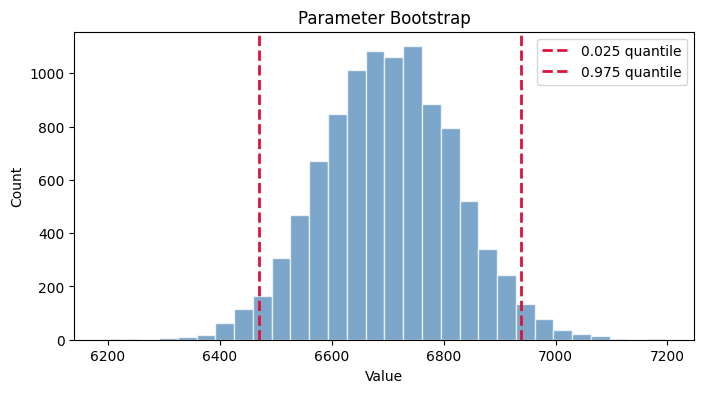

(np.float64(6470.48768515488), np.float64(6938.754957505388))

In [ ]:
# np.random.normal(loc= , scale= , size= )
n_trials = 10000
data = np.asarray(log_returns).squeeze()
n = len(data)

tau_mle = mle(data)
sim_pboot = np.empty(n_trials)

for i in range(n_trials):
    # generate data with tau_mle
    sim_data = np.random.normal(loc=mu, scale=np.sqrt(1/tau_mle), size=n)
    # calculate simulation mle for each simulation
    sim_pboot[i] = mle(sim_data)

# plot and find confidence interval
plot_quantile_hist(sim_pboot, title="Parameter Bootstrap")

### Frequentist — Nonparametric Bootstrapping

Core idea: take samples directly from the data, WITH REPLACEMENT, making no assumptions about the shape of the data-generating distribution

In [ ]:
n_trials = 10
n = len(log_returns)
data = np.asarray(log_returns).squeeze()

all_samples = np.random.choice(data, size=(n_trials, n), replace=True)
sim_npboot = mle(all_samples)

# plot and find confidence interval
plot_quantile_hist(sim_npboot, title="Nonparametric Bootstrap")

AttributeError: 'DataFrame' object has no attribute 'flatten'

### Bayesian — Metropolis-Hastings

We follow the following process:
1. Propose value $\tau^{(i)}$ from some distribution $g$. Generally, $g \sim N(\tau^{(i - 1)}, Var)$
2. Keep $\tau^{(i)}$ with probability $\mathrm{min} (\frac{f(\tau^{(i)})}{f(\tau^{(i - 1)})} , 1)$, otherwise keep $\tau^{(i - 1)}$, append to list
3. Repeat for some number of iterations, then use last K samples as simulation distribution

0.025 quantile: 6469.93
0.975 quantile: 6920.47


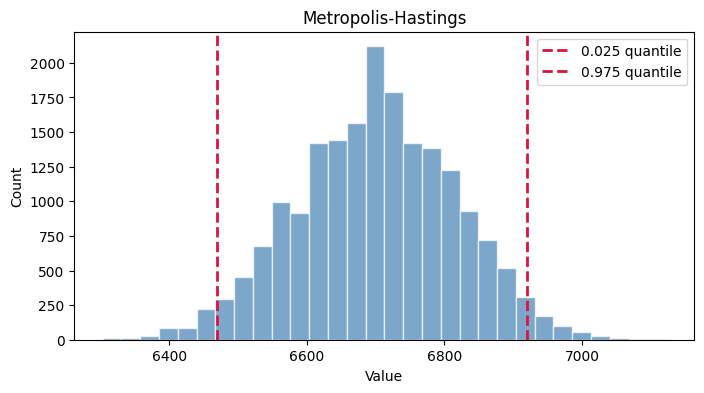

(np.float64(6469.928393497574), np.float64(6920.4712010521935))

In [ ]:
n_iter = 20000
burn_in = 1000
# np.random.normal(loc= , scale= , size= )

sampled_tau = []
tau_current = tau_mle
log_p_current = log_posterior(tau_current, np.asarray(log_returns).squeeze(), mu)
proposal_sd = 0.1 * tau_current

for _ in range(n_iter):
    # propose new tau
    tau_proposed = np.random.normal(tau_current, proposal_sd)
    log_p_proposed = log_posterior(tau_proposed, np.asarray(log_returns).squeeze(), mu)

    # accept with probability min(1, f(tau)/f(tau_proposed))
    accept_prob = min(1, np.exp(log_p_proposed - log_p_current))
    if np.random.uniform() < accept_prob:
        tau_current = tau_proposed
        log_p_current = log_p_proposed

    sampled_tau.append(tau_current)

# plot and find confidence interval
plot_quantile_hist(sampled_tau[:-burn_in], title="Metropolis-Hastings")



### Comparison

Key parameters

| Quantity | Value |
| --- | ---: |
| MLE tau | 6699.9624 |
| Posterior Gamma shape alpha_n | 3270.5000 |
| Posterior Gamma rate beta_n | 0.48803856 |
| Posterior mean for tau | 6701.3147 |

Intervals

| Interval | Lower | Upper |
| --- | ---: | ---: |
| Approx 95% CI for tau via substitution | 6470.2702 | 6929.6545 |
| Exact 95% CI for tau via inversion | 6477.8836 | 6937.8085 |
| Posterior 95% CI | 6473.5933 | 6932.9175 |
| Parameter Bootstrap CI |  |  |
| Nonparametric Bootstrap CI |  |  |
| Metropolis-Hastings CI |  |  |

## Chapter 7: Hypothesis Testing

After building confidence intervals, we now have a range of plausible values for market precision. But, something in your heart tells you that a range is too broad, and to be fully honest, a little boring. What we crave is something stronger -- we want to make a specific claim.

For example, suppose someone says: “The market has precision $\tau_0$,” or equivalently, “daily returns have variance $1/\tau_0$.” Our confidence interval can already give us a clue about whether that claim seems reasonable: if $\tau_0$ is far outside the interval, we become suspicious. 

Yet, we are unsatisfied, and so we approach Freddy for advice on a solution. It turns out that **hypothesis testing** gives Freddy a more formal language for this kind of decision.

Instead of asking, “What values of $\tau$ are plausible?” hypothesis testing asks, “If a particular value $\tau_0$ were true, would the data we observed look surprising?”

This is where Freddy feels especially at home. Since he thinks probability comes from repeated sampling, he imagines many datasets generated under the claim $H_0: \tau = \tau_0$. Then he compares our actual dataset to that repeated-sampling world. If our data would be very unusual under $H_0$, Freddy rejects the claim.

So in this chapter, we move from estimation to decision-making. In statistical terms, our null hypothesis represents the claim we are testing:

$$
H_0: \tau = \tau_0.
$$

The alternative hypothesis represents the direction (or later, set of possibilities) we are willing to consider if the null does not explain the data well:

$$
H_A: \tau < \tau_0 \quad \quad \text{ or } \quad \quad H_A: \tau > \tau_0
$$

The goal is not to prove that $H_0$ is true or false with certainty. Instead, the goal is to measure how surprising our data would be if $H_0$ were true.

### Choosing the Hypotheses

Now we need to choose a specific value of $\tau_0$ and a direction for the alternative. Since $\tau = 1/\sigma^2$, precision is easiest to interpret by translating it back into standard deviation. A natural benchmark might be that daily standard deviation is about 1%:

$$
\sigma_0 = 0.01.
$$

On the precision scale, this corresponds to

$$
\tau_0 = \frac{1}{\sigma_0^2} = \frac{1}{0.01^2} = 10000.
$$

And now, we want to test if the market is **more** volatile than that, meaning the variance is larger than $0.01^2$, which means the precision is smaller than $10000$. So the hypotheses I will test are

$$
H_0: \tau = 10000
$$

versus

$$
H_A: \tau < 10000.
$$

In words, the null says daily S&P 500 log returns have about 1% daily standard deviation. The alternative says the market is more volatile than that benchmark.


### The Likelihood Ratio

Now we can begin. Freddy suggests to start with the **Neyman-Pearson lemma**: if we had to choose between exactly two values, $\tau_0$ and some specific $\tau_A < \tau_0$, the most powerful level-$\alpha$ test rejects when the likelihood ratio is large:

$$\Lambda = \frac{f_{\tau_A}(x_1, \ldots, x_n)}{f_{\tau_0}(x_1, \ldots, x_n)} > c$$

where $c$ is chosen to make the size exactly $\alpha$. The logic is that we side with the explanation that makes the observed data more probable, and we set the threshold to control false rejections.

Recall our joint PMF

$$f_\tau(x_1, \ldots, x_n) = \left(\frac{\tau}{2\pi}\right)^{n/2} \exp\!\left(-\frac{\tau}{2}\sum_{i=1}^n x_i^2\right)$$

so the likelihood ratio becomes

$$\Lambda = \left(\frac{\tau_A}{\tau_0}\right)^{n/2} \exp\!\left(\frac{\tau_0 - \tau_A}{2}\sum_{i=1}^n x_i^2\right).$$

Since $\tau_A < \tau_0$, the coefficient $(\tau_0 - \tau_A)/2$ is strictly positive. This means $\Lambda$ is a strictly increasing function of $\sum_{i=1}^n x_i^2$. The Neyman-Pearson rule -- reject when $\Lambda > c$ -- translates directly into

$$\text{Reject } H_0 \text{ when } \sum_{i=1}^n x_i^2 > c.$$

### One Region Rules Them All

Now comes the elegant step. The threshold $c$ is determined entirely by the null distribution -- it depends on $\tau_0$ and $\alpha$, but not on which specific $\tau_1$ we chose. Whether the true precision is $9000$ or $500$, the rejection region is always $\left\{\sum x_i^2 > c\right\}$. The same test is simultaneously optimal against every $\tau_1 < \tau_0$.

This is what makes the test **uniformly most powerful**: no other level-$\alpha$ test can outperform it against any single alternative $\tau_1 < \tau_0$, which means no other test can outperform it against all of them at once.

The intuition is satisfying. A market with lower precision -- higher variance -- produces returns that stray further from zero. A large $\sum x_i^2$ is precisely the fingerprint of volatility. If the squared returns are collectively large, the data is making a case that something more dispersed than $\tau_0$ generated it.

---

### Finding the Critical Value

It remains to pin down $c$. Under $H_0: \tau = \tau_0$, each $x_i \sim N(0, \tau_0^{-1})$, so $\tau_0 x_i^2 \sim \chi^2_1$. By independence,

$$\chi^2_{\text{obs}} \;:=\; \tau_0 \sum_{i=1}^n x_i^2 \;\sim\; \chi^2_n \quad\text{under }H_0.$$

The rejection rule becomes

$$\text{Reject } H_0 \text{ if } \chi^2_{\text{obs}} > \chi^2_{n,\;0.95}$$

where $\chi^2_{n,\;0.95}$ is the upper 5% critical value of the chi-squared distribution with $n$ degrees of freedom.

---

### Applying the Test

With $n$ daily log-return observations from the S&P 500, we compute

$$\chi^2_{\text{obs}} = 10000 \times \sum_{i=1}^n x_i^2.$$

The $p$-value is

$$p = P_{\tau_0}\!\left(\chi^2_n > \chi^2_{\text{obs}}\right) = 1 - F_{\chi^2_n}\!\left(\chi^2_{\text{obs}}\right)$$

where $F_{\chi^2_n}$ is the chi-squared CDF. If $p < 0.05$, we reject $H_0$.

**[Plug in your computed $\chi^2_{\text{obs}}$ and $\chi^2_{n,\;0.95}$ here.]**

If $\chi^2_{\text{obs}} > \chi^2_{n,\;0.95}$: we reject $H_0: \tau = 10000$ at the 5% level. The data suggest that daily S&P 500 returns are more volatile than the 1% benchmark implies -- Freddy would say the repeated-sampling world under $\tau_0$ almost never produces data this extreme, so the null does not hold up.

If $\chi^2_{\text{obs}} \leq \chi^2_{n,\;0.95}$: we fail to reject. The observed dispersion is consistent with what $\tau_0 = 10000$ would routinely generate, and we have insufficient evidence to call the market more volatile than the benchmark.

### Finding the Critical Value

Under the null hypothesis,

$$
X_i \sim \mathcal N(0, 1/\tau_0).
$$

For this Normal model,

$$
\tau_0 S = \tau_0\sum_{i=1}^n X_i^2 \sim \chi^2_n.
$$

Because our alternative is $H_A: \tau < \tau_0$, we reject for large values of $S$, meaning we use the upper tail of the chi-square distribution. At significance level $\alpha = 0.05$, the UMP test is

$$
\text{Reject } H_0
\quad \text{if} \quad
\tau_0 S_{\text{obs}} > \chi^2_{n, 0.95}.
$$

Equivalently,

$$
\text{Reject } H_0
\quad \text{if} \quad
S_{\text{obs}} > \frac{\chi^2_{n, 0.95}}{\tau_0}.
$$

This test is uniformly most powerful for this one-sided alternative because the likelihood ratio is monotone in $S$: larger $S$ always gives stronger evidence for smaller $\tau$.


### Applying the Test

Now we apply the test to the observed S&P 500 log returns. The calculation needs four pieces:

$$
n, \qquad S_{\text{obs}} = \sum_{i=1}^n x_i^2, \qquad \tau_0 = 10000, \qquad \alpha = 0.05.
$$

Then we compare $\tau_0 S_{\text{obs}}$ to the $0.95$ quantile of a chi-square distribution with $n$ degrees of freedom.


In [10]:
tau_0 = 10000
alpha = 0.05

x = np.asarray(log_returns).squeeze()
n = len(x)
S_obs = np.sum(x ** 2)

test_stat = tau_0 * S_obs
critical_value = stats.chi2.ppf(1 - alpha, df=n)
p_value = 1 - stats.chi2.cdf(test_stat, df=n)

print(f"n: {n}")
print(f"S_obs: {S_obs:.6f}")
print(f"Test statistic tau_0 * S_obs: {test_stat:.4f}")
print(f"Critical value chi-square_{{n, 0.95}}: {critical_value:.4f}")
print(f"p-value: {p_value:.6f}")
print("Reject H0" if test_stat > critical_value else "Fail to reject H0")


n: 6537
S_obs: 0.975677
Test statistic tau_0 * S_obs: 9756.7712
Critical value chi-square_{n, 0.95}: 6726.2053
p-value: 0.000000
Reject H0


### Conclusion

At significance level $\alpha = 0.05$, the decision rule is simple: if the test statistic is larger than the chi-square critical value, we reject $H_0: \tau = 10000$ in favor of $H_A: \tau < 10000$.

In the language of the data, rejecting $H_0$ means the observed returns are too spread out to be consistent with the 1% daily standard deviation benchmark. Since smaller $\tau$ means larger variance, rejection would be evidence that daily S&P 500 returns are more volatile than the benchmark. If we fail to reject, then the data do not give enough evidence, at the 5% level, to say the market is more volatile than that benchmark.


## Chapter 8: Generalized Likelihood Ratio Test

Continuing the hypothesis test that you did last week, derive the generalized likelihood ratio test for 
- $H_0: \tau = \tau_0$
- $H_A: \tau \neq \tau_0$

If possible, try to simplify the generalized likelihood ratio test statistic and obtain an exact test. If not, use Wilks' theorem to obtain an approximate test.

See if you can plot the power curve as a function of values of $\tau$ under the alternative hypothesis.

By the Generalized Likelihood Ratio Test, we reject the null hypothesis when

$$
\frac{\max_{\tau} L_{X_1, \ldots, X_n} (\tau)}{L_{X_1, \ldots, X_n} (\tau_0)} \geq c
$$

And we have normal pdf:

$$
\sqrt{\frac{\tau}{2 \pi}} \exp(-\frac \tau2 (x - \mu)^2)
$$

Which makes the GLRT with MLE $\hat \tau = \frac{n}{\sum (x_i - \mu)^2}$:

\begin{align*}
\Lambda
&= 
\frac{(\frac{\hat \tau}{2 \pi})^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2)}
{(\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum(x_i - \mu)^2)}\\
&=
\frac{ \hat \tau^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2)}
{ \tau_0^{n/2} \exp(-\frac {\tau_0}{2} \sum(x_i - \mu)^2)} \\
&=
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2 + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\
&= 
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac{n}{2\sum (x_i - \mu)^2} \sum(x_i - \mu)^2 + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\
&=
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac{n}{2} + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\

\log \Lambda &=
\frac{n}{2} (\log \hat \tau - \log \tau_0) -\frac{n}{2} + \frac {\tau_0}{2} \sum(x_i - \mu)^2 \\

2 \log \Lambda &=
n (\log \hat \tau - \log \tau_0) -n + \tau_0 \sum(x_i - \mu)^2  \\
&=
n (\log \hat \tau - \log \tau_0) -n + n\frac{\tau_0}{\hat \tau} \\
&= 
n(\log \frac{\hat \tau}{\tau_0} + \frac{\tau_0}{\hat \tau} - 1)
\end{align*}

Now, applying Wilks', we get:

$$
\log \Lambda  = n(\log \frac{\hat \tau}{\tau_0} + \frac{\tau_0}{\hat \tau} - 1) \geq \chi^2_1
$$


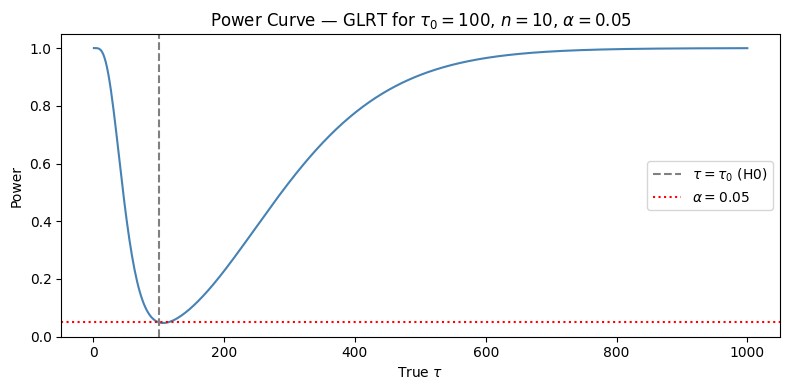

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parameters
n = 10
tau_0 = 100
significance_level = 0.05

# Critical values under H0
c1 = chi2.ppf(significance_level / 2, df=n)
c2 = chi2.ppf(1 - significance_level / 2, df=n)

# Grid of true tau values
tau_grid = np.linspace(1, 1000, 500)

# maybe can use wilks instead of this formula

# Power at each true tau
# t ~ (tau_0/tau) * chi2_n, so rescale critical values by tau/tau_0
def power(tau):
    scale = tau / tau_0
    return chi2.cdf(scale * c1, df=n) + (1 - chi2.cdf(scale * c2, df=n))

pow_vals = [power(tau) for tau in tau_grid]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(tau_grid, pow_vals, color='steelblue')
plt.axvline(tau_0, color='gray', linestyle='--', label=r'$\tau = \tau_0$ (H0)')
plt.axhline(significance_level, color='red', linestyle=':', label=rf'$\alpha = {significance_level}$')
plt.xlabel(r'True $\tau$')
plt.ylabel('Power')
plt.title(rf'Power Curve — GLRT for $\tau_0={tau_0}$, $n={n}$, $\alpha={significance_level}$')
plt.legend()
plt.tight_layout()
plt.show()

## Chapter 9: Bayesian Hypothesis Testing & Bayes Factor

$H_0: \tau = \tau_0$

$H_A: \tau = \tau_A$

$$
\frac{P(H_A | X)}{P(H_0 | X)} * \frac{P(H_A)}{P(H_0)}
$$
Suppose $P(H_A) = 0.9$, $P(H_0) = 0.1$
$$
\frac{P(H_A | X)}
{ \prod \sqrt{\frac{\tau_0}{2 \pi}} \exp(-\frac {\tau_0}{2} (x - \mu)^2)} 
* \frac{0.9}{0.1}
$$

$$
\frac{
    \int_0^\infty
    \bigg( (\frac{\tau}{2 \pi})^{n/2} \exp(-\frac {\tau}{2} \sum (x_i - \mu)^2) \bigg)
    \bigg ( \frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)} 
    \tau^{\alpha_0 - 1} \exp(- \beta_0 \tau) \bigg) d \tau
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    (2\pi)^{-n/2}
    \frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)} 
    \int_0^\infty
    \bigg( (\tau)^{\alpha_0 + n/2 - 1} \exp(- \tau ( \beta_0 + \frac {1}{2} \sum (x_i - \mu)^2) ) \bigg) d \tau
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    (2\pi)^{-n/2}
    \frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)} 
    \frac{\Gamma(\alpha_n)}{\beta_n^{\alpha_n}}
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    \beta_0^{\alpha_0} \Gamma(\alpha_n)
    \exp(\frac {\tau_0}{2} \sum (x_i - \mu)^2)
}
{ \Gamma(\alpha_0) \beta_n^{\alpha_n} (\tau_0)^{n/2} } 
* 9
$$


## Chapter 10: Sufficient Statistics

<div style="border-left: 3px solid gray; padding-left: 10px; margin: 10px 0;">

Def: A statistic $T(X_1, \ldots, X_n)$ is **sufficient** if either of the following holds

1. $f_\theta (X_1, \ldots, X_n) = g(\theta, T(X_1, \ldots, X_n)) h(X_1, \ldots, X_n)$. In other words, the PMF/PDF factorizes into two pieces:
    - $g$, which depends on the data only through $T$.
    - $h$, which only depends on data, not $\theta$.
2. The distribution of 
    $$ X_1, \ldots, X_n \mid T = t $$
    does not depend on $\theta$. 

</div>

For our distribution, we have

$$
f_\tau (x_1, \ldots, x_n)  = (\frac{\tau}{2 \pi})^{n/2} \exp( -\frac \tau2 \sum x_i^2)
$$

and we want to factor this into a piece that depends on the data ($x_1,\ldots, x_n$) only through T, and another piece which only depends on the data and not $\tau$. Pretty simply, we can set 
$$T(x_1,\ldots, x_n) = \sum_{i =1}^{n} x_i^2$$

as our sufficient statistic Then our joint PDF factors into

$$
f_\theta (x_1, \ldots, x_n)  = \underbrace{(\frac{\tau}{2 \pi})^{n/2} \exp( -\frac \tau2 T(x))}_{g(\tau, T(x))} \cdot \underbrace1_{h(x)}.
$$

